   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  2017-11-08  2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156  2017-11-08  2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688  2017-06-12  2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966  2016-10-11  2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966  2016-10-11  2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   Sout

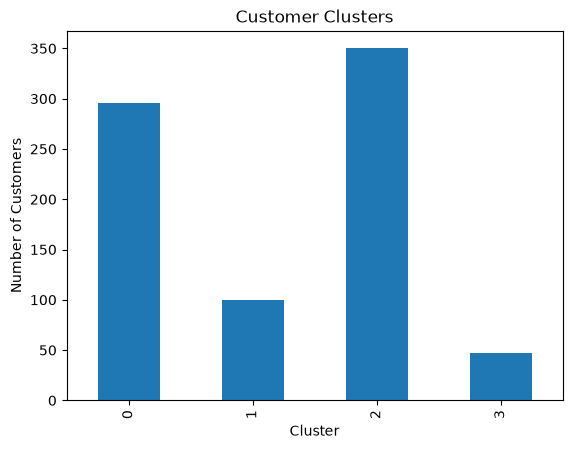


NLP Clusters:
                                        Product Name  NLP_Cluster
0                  Bush Somerset Collection Bookcase            1
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...            3
2  Self-Adhesive Address Labels for Typewriters b...            1
3      Bretford CR4500 Series Slim Rectangular Table            1
4                     Eldon Fold 'N Roll Cart System            1
5  Eldon Expressions Wood and Plastic Desk Access...            1
6                                         Newell 322            1
7                     Mitel 5320 IP Phone VoIP phone            1
8  DXL Angle-View Binders with Locking Rings by S...            1
9                   Belkin F5C206VTEL 6 Outlet Surge            1
Cluster 0 : gbc, binding, covers, plastic, ibico
Cluster 1 : avery, binders, newell, ring, binder
Cluster 2 : xerox, 1881, 1893, 1898, 226
Cluster 3 : chair, global, chairs, task, leather


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# Load dataset
df = pd.read_csv("Superstore.csv")
print(df.head())

# -------- K-MEANS --------
customer = df.groupby("Customer ID")[["Sales","Quantity","Discount","Profit"]].sum()

X = StandardScaler().fit_transform(customer)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
customer["Cluster"] = km.fit_predict(X)

print("\nCustomer Clusters:")
print(customer.groupby("Cluster").mean())

# Plot K-Means
customer["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

# -------- NLP --------
text = df["Product Name"].fillna("").str.lower()

tfidf = TfidfVectorizer(stop_words="english")
X_text = tfidf.fit_transform(text)

nlp = KMeans(n_clusters=4, random_state=42, n_init=10)
df["NLP_Cluster"] = nlp.fit_predict(X_text)

print("\nNLP Clusters:")
print(df[["Product Name","NLP_Cluster"]].head(10))

# Important words
words = tfidf.get_feature_names_out()

for i in range(4):
    top = nlp.cluster_centers_[i].argsort()[-5:][::-1]
    print("Cluster", i, ":", ", ".join(words[j] for j in top))